## NX-414: Brain-like computation and intelligence
Notebook prepared by Alessandro Marin Vargas

# Week 6 - Mini project (Predicting neural activity)

The objectives of the mini project are:
- Learn how to predict neural activity using linear regression from images and from neural network layers.
- Quantify the goodness of the model
- Compare the results across the network layers and between trained/random neural network
- Predict the neural activity using a neural network in a data-driven approach

Specifically, here you will use the data from the following [paper](https://www.jneurosci.org/content/jneuro/35/39/13402.full.pdf). The behavioral experiment consisted in showing to non-human primates some images while recording the neural activity with multielectrode arrays from the inferior temporal (IT) cortex. In the data we provided you, the neural activity and the images are already pre-processed and you will have available the images and the corresponding average firing rate (between 70 and 170 ms) per each neuron.

### Deadline for Mini-Project Submission: May 7, 2025

You are required to submit your mini-projects by midnight on 07/05/25. Please upload a .zip file to Moodle containing your code, along with the following specific components:

- One-Page Report (Report.pdf): This should detail your investigative process and include:
    - A comparison table of models. This should cover linear regression from stimuli, both trained and random task-driven models, data-driven models, and your best-performing model.
    - A figure illustrating the variation in neural prediction across different layers of a task-driven model.
    - Your exploration to develop the most effective model at predicting IT neural activity
- Example Script/Notebook: Please provide a script (test.py) or a notebook (test.ipynb) demonstrating how your best model performs on the validation set. This should serve as an example of the model's usage.

In [1]:
import sys
!{sys.executable} -m pip install gdown h5py

In [2]:
from utils import load_it_data, visualize_img
import matplotlib.pyplot as plt
import numpy as np
import gdown
import os
url = "https://drive.google.com/file/d/1s6caFNRpyR9m7ZM6XEv_e8mcXT3_PnHS/view?usp=share_link"
output = "IT_data.h5"
if not os.path.exists(output):
    gdown.download(url, output, quiet=False, fuzzy=True)


### Load the data

In [3]:
path_to_data = '' ## Insert the folder where the data is, if you download in the same folder as this notebook then leave it blank

stimulus_train, stimulus_val, stimulus_test, objects_train, objects_val, objects_test, spikes_train, spikes_val = load_it_data(path_to_data)


In [4]:
n_stimulus, n_channels, img_size, _ = stimulus_train.shape
_, n_neurons = spikes_train.shape
print('The train dataset contains {} stimuli and {} IT neurons'.format(n_stimulus,n_neurons))
print('Each stimulus have {} channgels (RGB)'.format(n_channels))
print('The size of the image is {}x{}'.format(img_size,img_size))

The train dataset contains 2592 stimuli and 168 IT neurons
Each stimulus have 3 channgels (RGB)
The size of the image is 224x224


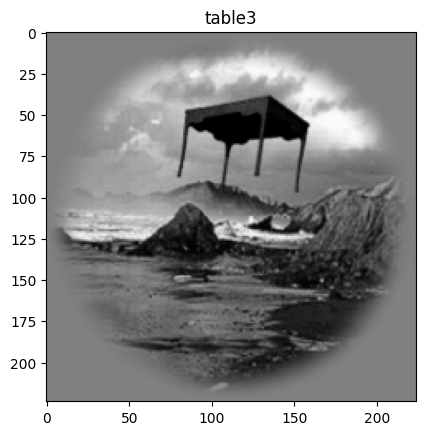

In [5]:
stim_idx = 1

visualize_img(stimulus_train,objects_train,stim_idx)

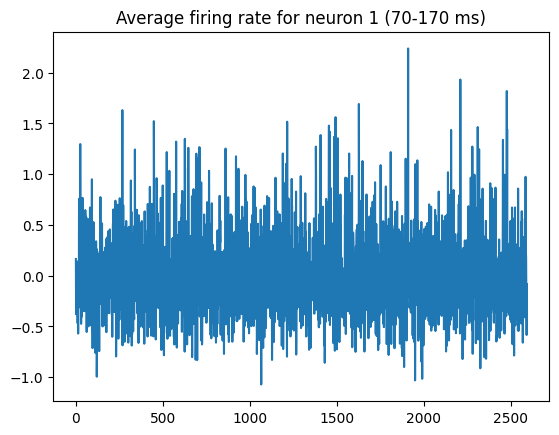

In [6]:
neuron_idx = 1

plt.figure()
plt.title('Average firing rate for neuron {} (70-170 ms)'.format(neuron_idx))
plt.plot(spikes_train[:,neuron_idx])

## Part 1: Predict the neural activity from pixels

##### Develop a linear regression model that predict the neural activity from pixels.
You can try out different types of linear regression (ridge, least-square regression)

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from scipy.stats import pearsonr
from sklearn.metrics import explained_variance_score

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
import seaborn as sns

##### Evaluate your prediction (Check both the correlation and explained variance for each neuron). Plot the distribution for the explained variance across neurons.

In [8]:
# Reshape the data
X_train = stimulus_train.reshape(stimulus_train.shape[0], -1)
X_val = stimulus_val.reshape(stimulus_val.shape[0], -1)
X_test = stimulus_test.reshape(stimulus_test.shape[0], -1)
y_train = spikes_train.reshape(spikes_train.shape[0], -1)
y_val = spikes_val.reshape(spikes_val.shape[0], -1)

In [9]:
# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [10]:
def evaluate_model(model, X: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Evaluate a model using Pearson correlation and explained variance.

    Parameters:
    - model: Trained model with a `predict` method.
    - X (np.ndarray): Input data of shape (n_samples, n_features).
    - y (np.ndarray): True output data of shape (n_samples, n_targets).

    Returns:
    - tuple[np.ndarray, np.ndarray]: A tuple containing:
        - corr (np.ndarray): Pearson correlation for each output dimension, shape (n_targets,).
        - evar (np.ndarray): Explained variance for each output dimension, shape (n_targets,).
    """

    # Predict the output using the model
    y_pred = model.predict(X)

    # Compute Pearson correlation for all dimensions
    corr = np.array([pearsonr(y[:, i], y_pred[:, i])[0] for i in range(y.shape[1])])

    # Compute explained variance for all dimensions
    evar = explained_variance_score(y, y_pred, multioutput='raw_values')

    return corr, evar


In [11]:
def plot_ev_distributions(ev_list: list[np.ndarray], models: list[str], kde:bool=True) -> None:
    """
    Plot the distribution of explained variance (ev) across neurons for multiple models.

    Parameters:
    - ev_list (list[np.ndarray]): List of arrays of explained variance values for each neuron, one per model.
    - model_names (list[str]): List of model names corresponding to the EV arrays.
    - kde (bool): If True, use Kernel Density Estimation for visualization.
    """
    plt.figure(figsize=(12, 6))
    for ev, model in zip(ev_list, models):
        if kde:
            sns.kdeplot(ev, label=model, fill=True, alpha=0.5)
        else:
            plt.hist(ev, bins=30, alpha=0.7, label=model, edgecolor='black')
    title = "Distribution of explained variance across neurons"
    if len(models) == 1:
        title += f" - {models[0]}"
    plt.title(title)
    plt.xlabel("Explained variance")
    plt.ylabel("Number of neurons")
    plt.legend()
    plt.grid(alpha=0.75)
    plt.show()

##### Linear Regression

In [12]:
# Linear regression
linear = LinearRegression()
linear.fit(X_train, y_train)

LinearRegression()

In [13]:
# Results
corr_linear, ev_linear = evaluate_model(linear, X_val, y_val)
mean_corr_linear, mean_ev_linear = np.mean(corr_linear), np.mean(ev_linear)
model_linear = "Linear Regression"
print(model_linear)
print("Mean pearson correlation: {:.4f}".format(mean_corr_linear))
print("Mean explained variance: {:.4f}".format(mean_ev_linear))

Linear Regression
Mean pearson correlation: 0.2203
Mean explained variance: -0.0374


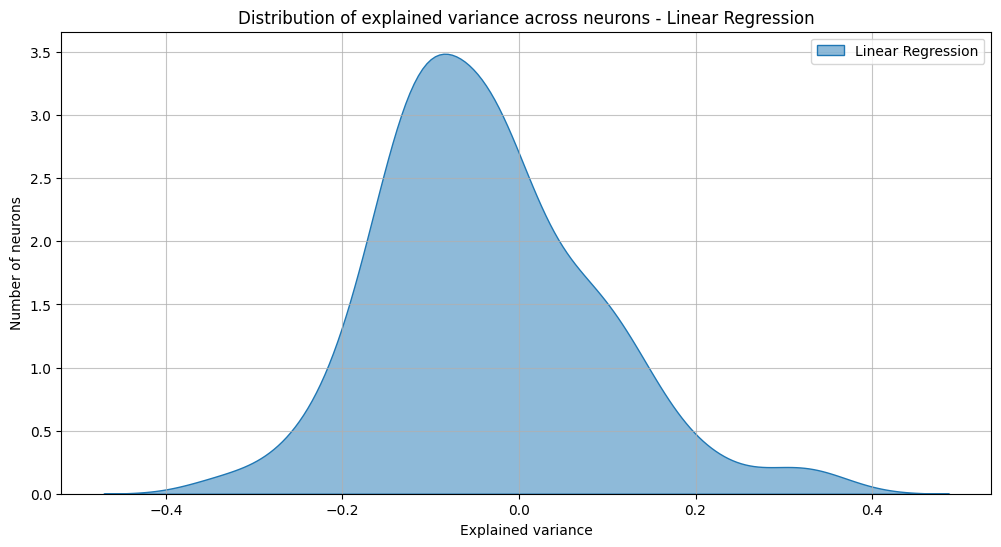

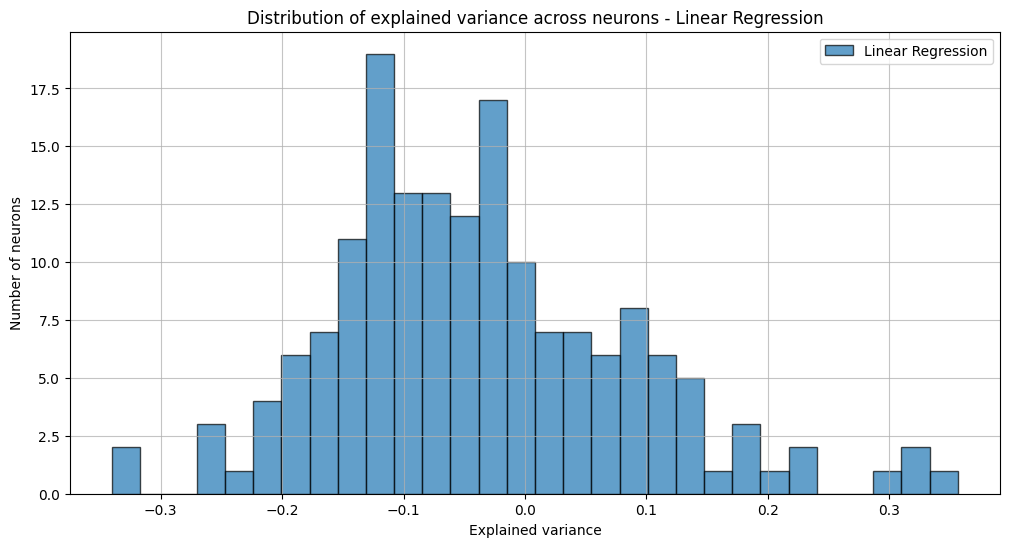

In [14]:
plot_ev_distributions([ev_linear], [model_linear], kde=True)
plot_ev_distributions([ev_linear], [model_linear], kde=False)

##### Ridge regression with $\alpha$=100

In [15]:
# Ridge regression with alpha = 100
ridge = Ridge(alpha=100)
ridge.fit(X_train, y_train)

Ridge(alpha=100)

In [16]:
# Results
corr_ridge, ev_ridge = evaluate_model(ridge, X_val, y_val)
mean_corr_ridge, mean_ev_ridge = np.mean(corr_ridge), np.mean(ev_ridge)
model_ridge = r"Ridge Regression ($\alpha=100$)"
print(model_ridge)
print("Mean pearson correlation: {:.4f}".format(mean_corr_ridge))
print("Mean explained variance: {:.4f}".format(mean_ev_ridge))

Ridge Regression ($\alpha=100$)
Mean pearson correlation: 0.1708
Mean explained variance: -0.7894


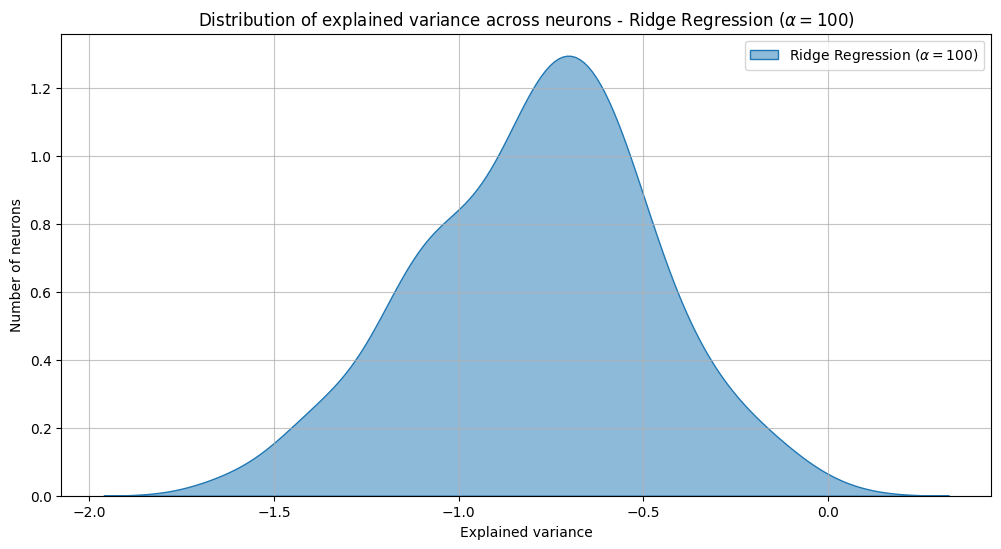

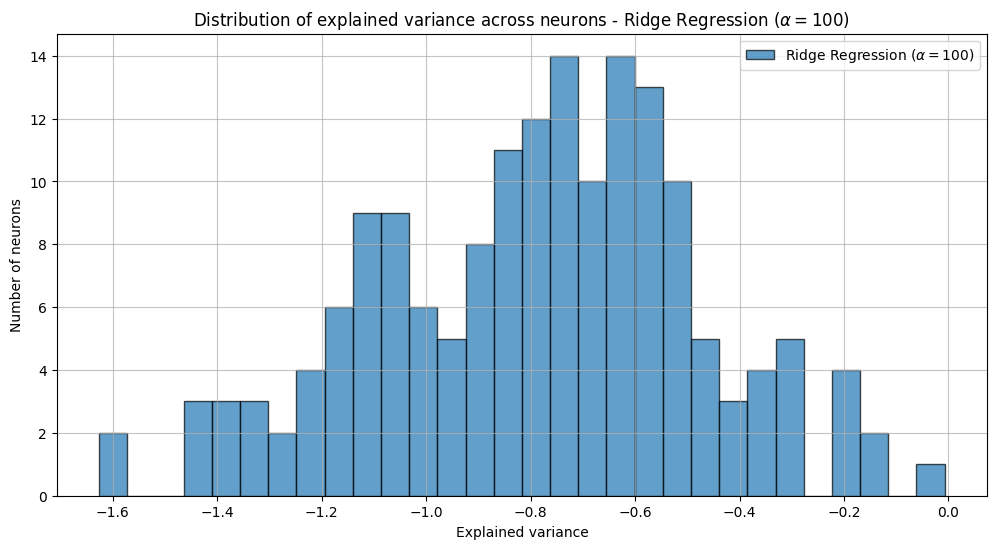

In [17]:
plot_ev_distributions([ev_ridge], [model_ridge], kde=True)
plot_ev_distributions([ev_ridge], [model_ridge], kde=False)

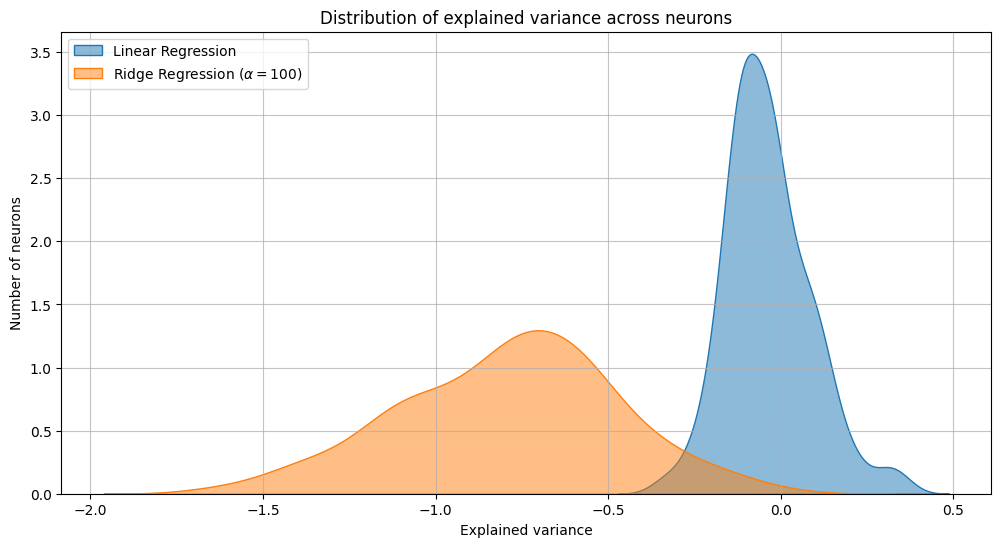

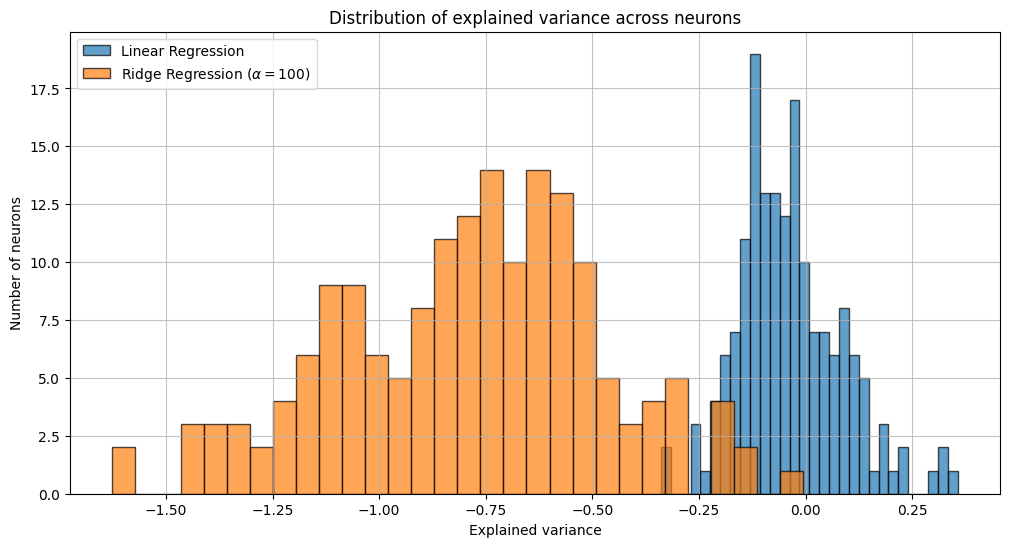

In [18]:
# Visual comprison of the two models
plot_ev_distributions([ev_linear, ev_ridge], [model_linear, model_ridge], kde=True)
plot_ev_distributions([ev_linear, ev_ridge], [model_linear, model_ridge], kde=False)

##### Predicting from pixels is very hard and the model is likely to overfit. An image is very high-dimensional, try to retain the corresponding 1000 PCs and use them to predict the neural activity. 

In [19]:
# PCA
pca = PCA(n_components=1000)
pca.fit(X_train)
X_train_pca = pca.transform(X_train)
X_val_pca = pca.transform(X_val)

##### Linear Regression on PCA

In [20]:
# Linear regression on PCA
linear_pca = LinearRegression()
linear_pca.fit(X_train_pca, y_train)

LinearRegression()

In [21]:
# Results
corr_linear_pca, ev_linear_pca = evaluate_model(linear_pca, X_val_pca, y_val)
mean_corr_linear_pca, mean_ev_linear_pca = np.mean(corr_linear_pca), np.mean(ev_linear_pca)
model_linear_pca = "Linear Regression on PCA"
print(model_linear_pca)
print("Mean pearson correlation: {:.4f}".format(mean_corr_linear_pca))
print("Mean explained variance: {:.4f}".format(mean_ev_linear_pca))

Linear Regression on PCA
Mean pearson correlation: 0.2174
Mean explained variance: -0.0775


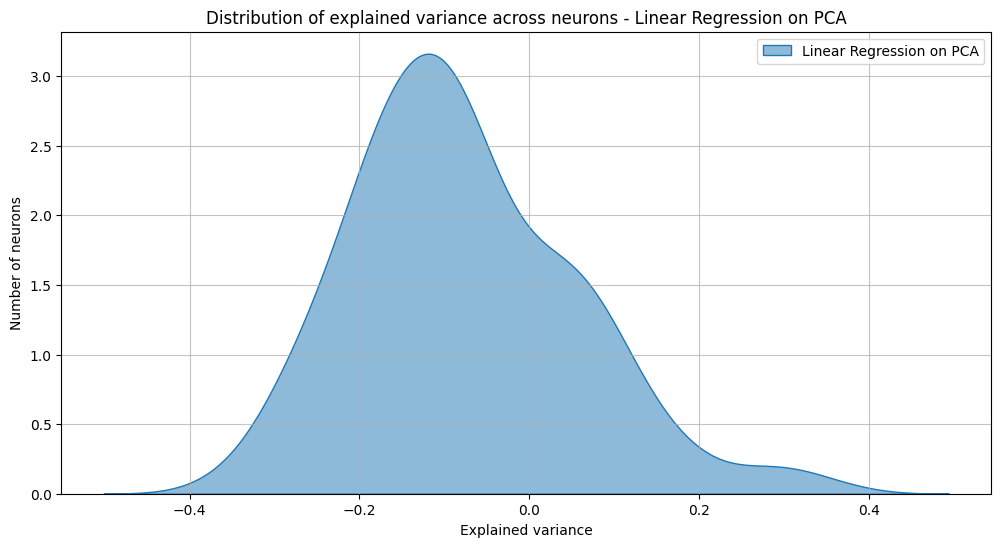

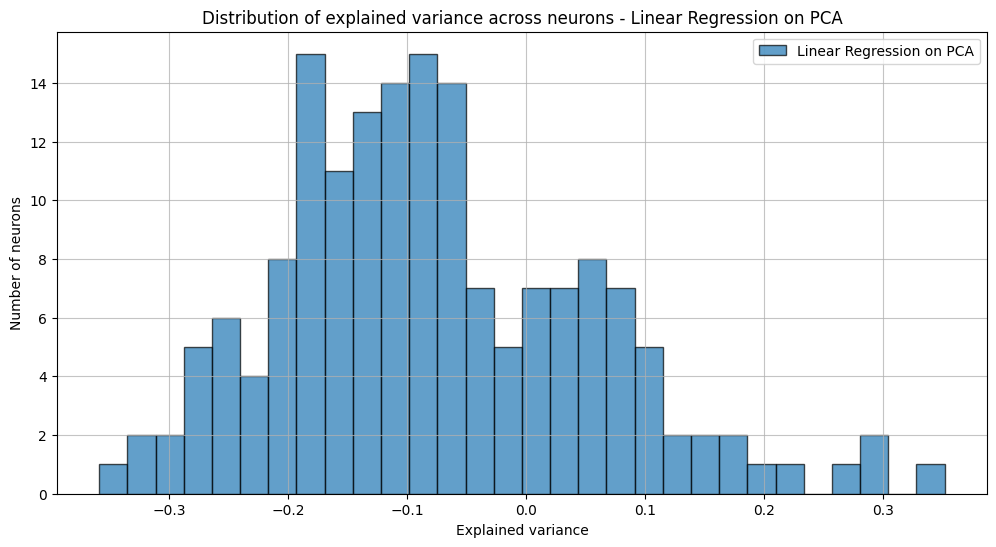

In [22]:
plot_ev_distributions([ev_linear_pca], [model_linear_pca], kde=True)
plot_ev_distributions([ev_linear_pca], [model_linear_pca], kde=False)

##### Ridge regression with $\alpha=100$ on PCA

In [23]:
# Ridge regression on PCA
ridge_pca = Ridge(alpha=100)
ridge_pca.fit(X_train_pca, y_train)

Ridge(alpha=100)

In [24]:
# Results
corr_ridge_pca, ev_ridge_pca = evaluate_model(ridge_pca, X_val_pca, y_val)
mean_corr_ridge_pca, mean_ev_ridge_pca = np.mean(corr_ridge_pca), np.mean(ev_ridge_pca)
model_ridge_pca = r"Ridge Regression on PCA ($\alpha=100$)"
print(model_ridge_pca)
print("Mean pearson correlation: {:.4f}".format(mean_corr_ridge_pca))
print("Mean explained variance: {:.4f}".format(mean_ev_ridge_pca))

Ridge Regression on PCA ($\alpha=100$)
Mean pearson correlation: 0.2177
Mean explained variance: -0.0762


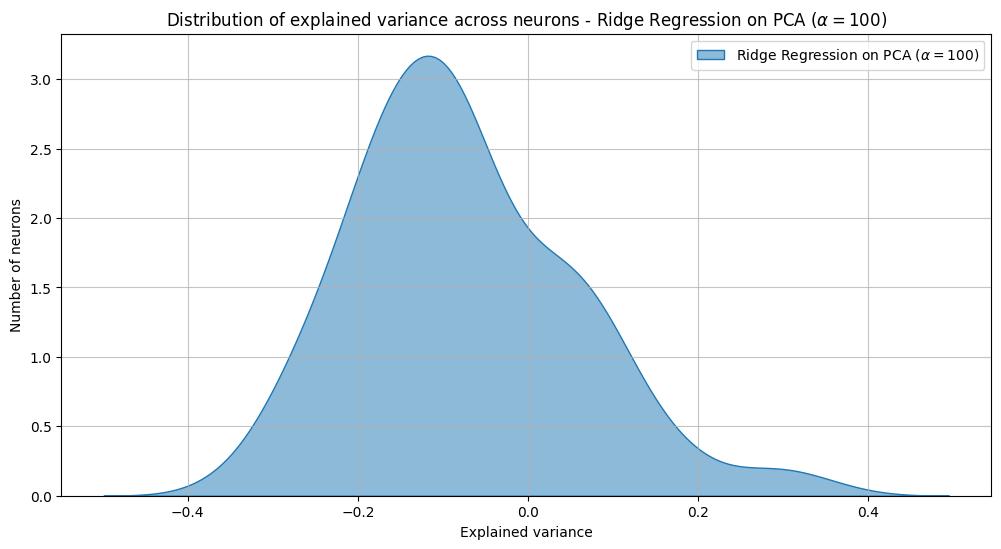

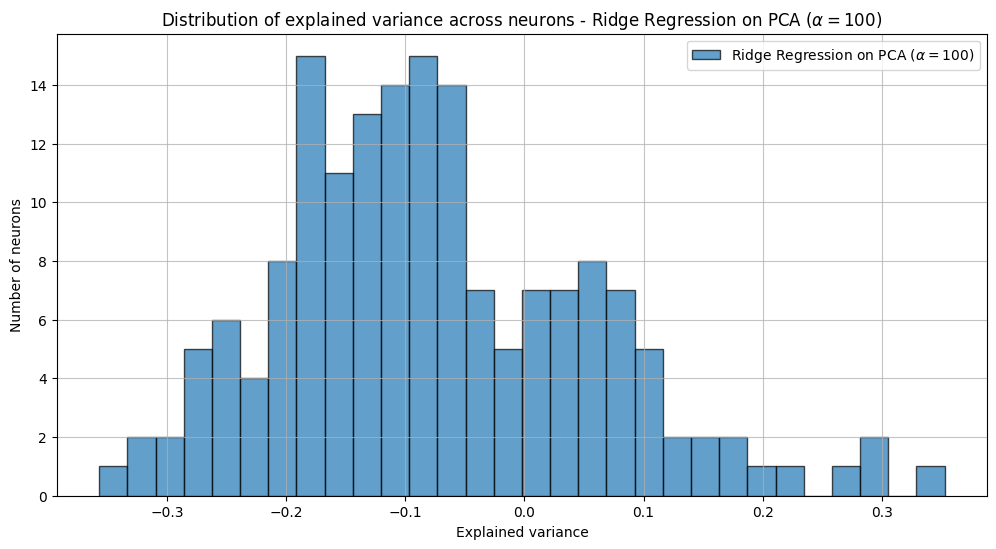

In [25]:
plot_ev_distributions([ev_ridge_pca], [model_ridge_pca], kde=True)
plot_ev_distributions([ev_ridge_pca], [model_ridge_pca], kde=False)

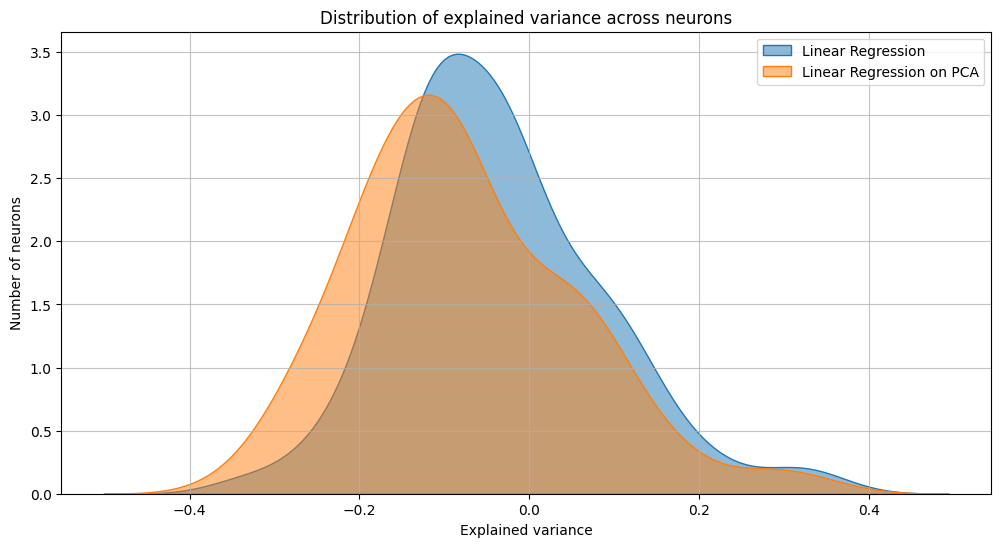

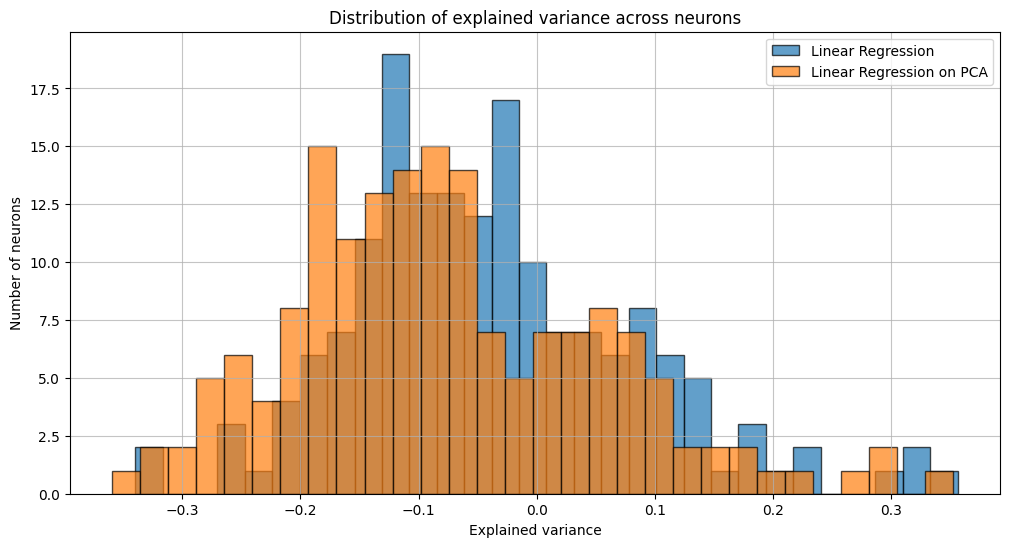

In [26]:
# Comparison linear before and after PCA
plot_ev_distributions([ev_linear, ev_linear_pca], [model_linear, model_linear_pca], kde=True)
plot_ev_distributions([ev_linear, ev_linear_pca], [model_linear, model_linear_pca], kde=False)

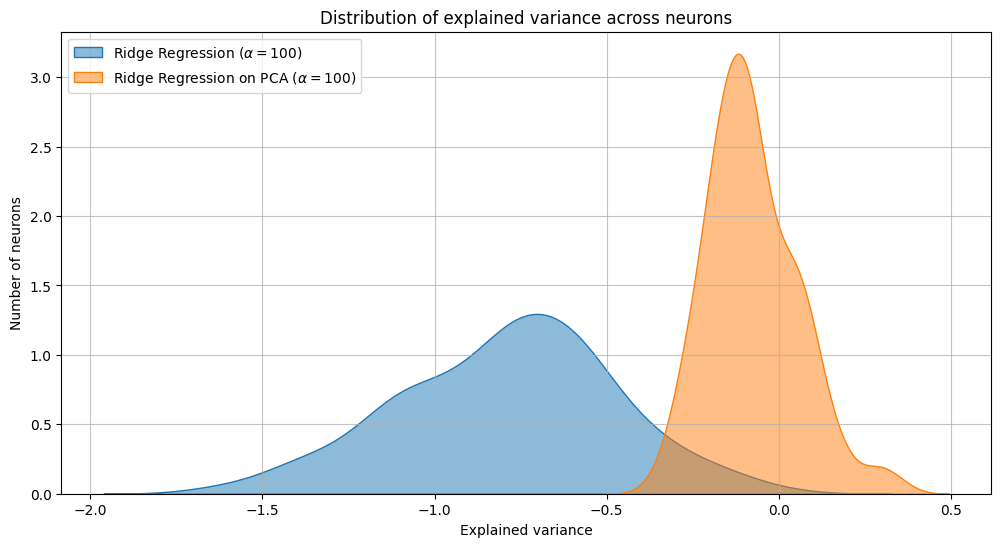

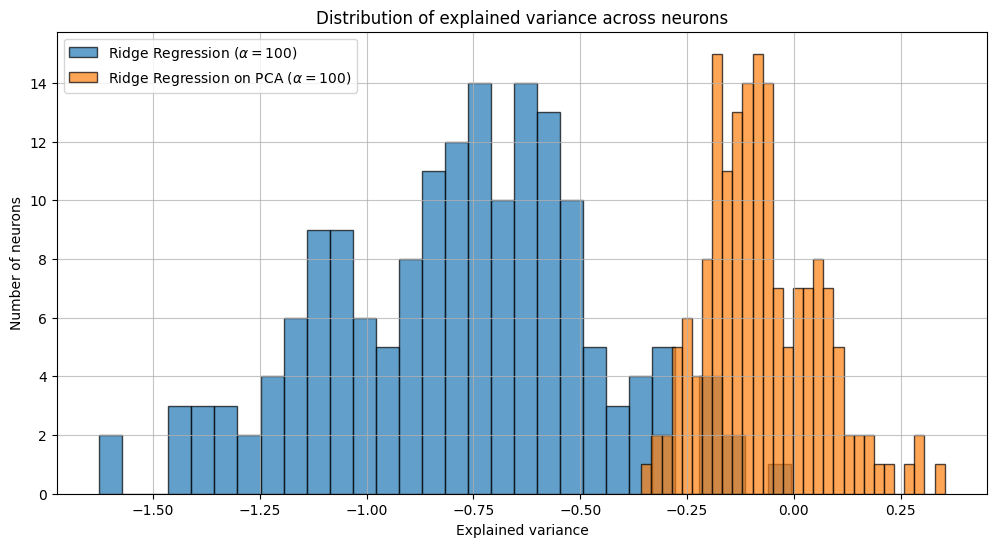

In [27]:
# Comparison of ridge before and after PCA
plot_ev_distributions([ev_ridge, ev_ridge_pca], [model_ridge, model_ridge_pca], kde=True)
plot_ev_distributions([ev_ridge, ev_ridge_pca], [model_ridge, model_ridge_pca], kde=False)

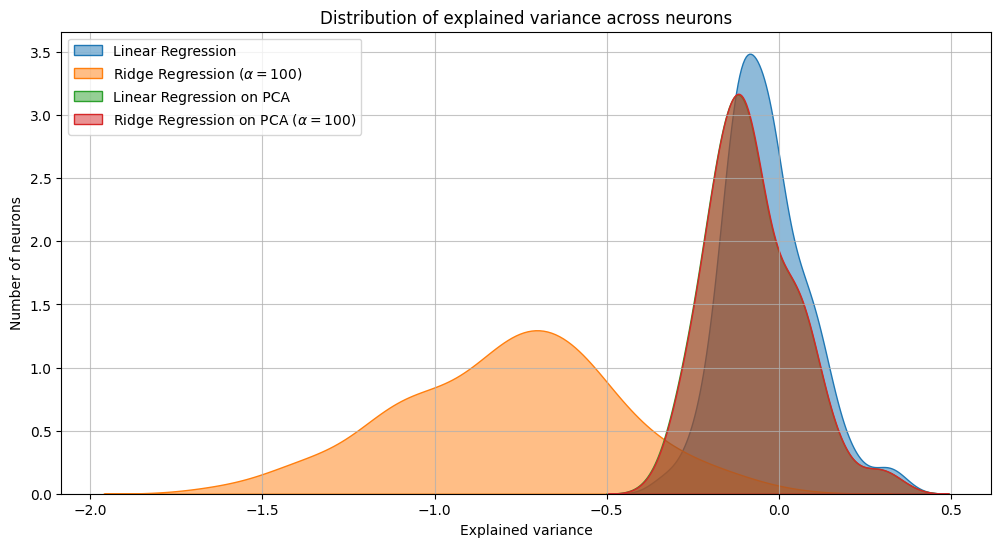

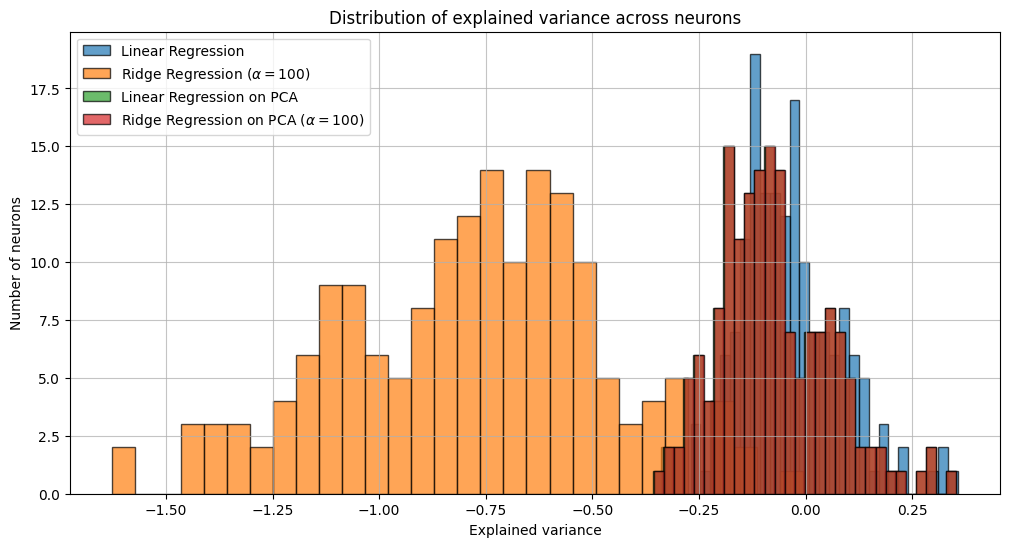

In [28]:
# Compare all models
plot_ev_distributions([ev_linear, ev_ridge, ev_linear_pca, ev_ridge_pca], 
                      [model_linear, model_ridge, model_linear_pca, model_ridge_pca], kde=True)
plot_ev_distributions([ev_linear, ev_ridge, ev_linear_pca, ev_ridge_pca],
                      [model_linear, model_ridge, model_linear_pca, model_ridge_pca], kde=False)

##### Can we improve the prediction? Using the ridge regression, find the best parameter with cross-fold validation (remember to split the data keeping the same distribution of classes between the train and validation set). Does it get better?

##### Tuned ridge regression without pca

In [30]:
# Define the range of alpha values
alphas = np.logspace(0, 8, 50)

# Perform Ridge regression with cross-validation
ridge_cv = RidgeCV(alphas=alphas, scoring='explained_variance', cv=5)
ridge_cv.fit(X_train, y_train)

# Get the best alpha
best_alpha = ridge_cv.alpha_

print(f"Best alpha: {best_alpha}")

/Users/daniel/NSSP_Project2/fsl/envs/nx414/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/daniel/NSSP_Project2/fsl/envs/nx414/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/daniel/NSSP_Project2/fsl/envs/nx414/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/daniel/NSSP_Project2/fsl/envs/nx414/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/daniel/NSSP_Project2/fsl/envs/nx414/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular ma

Best alpha: 355648.03062231286
Best Ridge Regression
Mean pearson correlation: 0.2866
Mean explained variance: 0.0933


In [33]:
# Results
corr_best_ridge, ev_best_ridge = evaluate_model(ridge_cv, X_val, y_val)
mean_corr_best_ridge, mean_ev_best_ridge = np.mean(corr_best_ridge), np.mean(ev_best_ridge)
model_best_ridge = r"Best Ridge Regression ($\alpha={:.2f}$)".format(best_alpha)
print(model_best_ridge)
print("Mean pearson correlation: {:.4f}".format(mean_corr_best_ridge))
print("Mean explained variance: {:.4f}".format(mean_ev_best_ridge))

Best Ridge Regression ($\alpha=355648.03$)
Mean pearson correlation: 0.2866
Mean explained variance: 0.0933


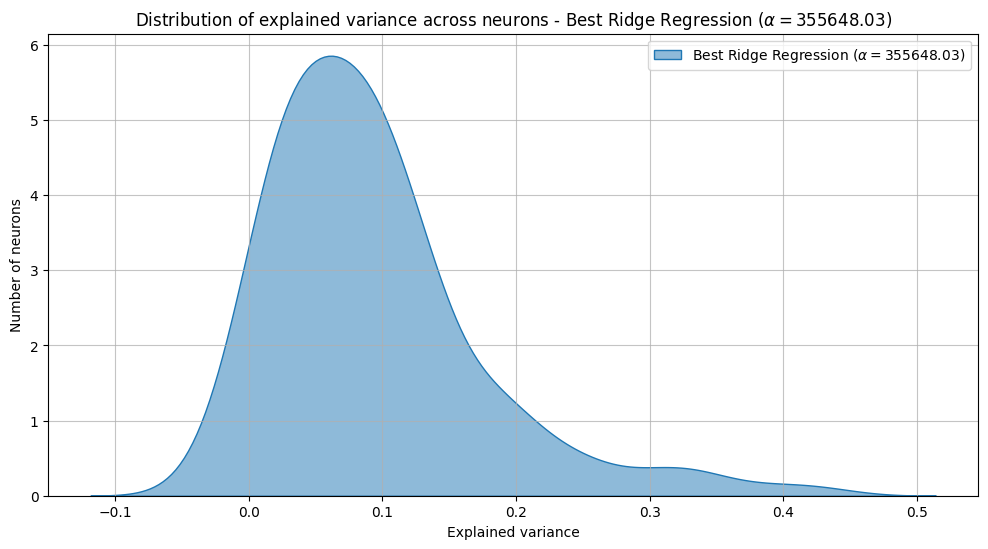

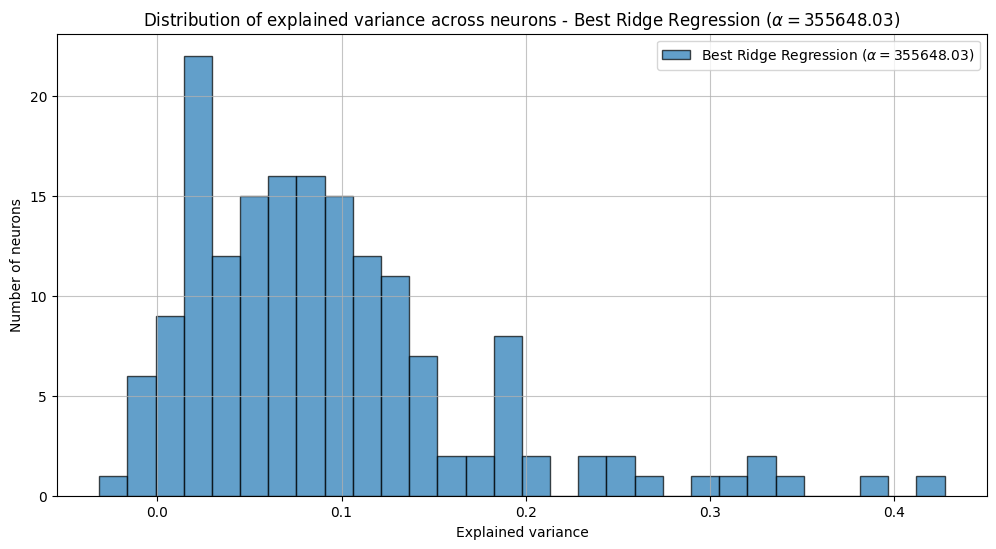

In [34]:
plot_ev_distributions([ev_best_ridge], [model_best_ridge], kde=True)
plot_ev_distributions([ev_best_ridge], [model_best_ridge], kde=False)

##### Tuned ridgeregression with pca

In [40]:
# Perform Ridge regression with cross-validation
ridge_cv_pca = RidgeCV(alphas=alphas, scoring='explained_variance', cv=5)
ridge_cv_pca.fit(X_train_pca, y_train)

# Get the best alpha
best_alpha_pca = ridge_cv.alpha_

print(f"Best alpha: {best_alpha_pca}")

Best alpha: 355648.03062231286


In [41]:
# Evaluate the best model on the validation set
corr_best_ridge_pca, ev_best_ridge_pca = evaluate_model(ridge_cv_pca, X_val_pca, y_val)
mean_corr_best_ridge_pca, mean_ev_best_ridge_pca = np.mean(corr_best_ridge), np.mean(ev_best_ridge)
model_best_ridge_pca = r"Best Ridge Regression on PCA ($\alpha={:.2f}$)".format(best_alpha_pca)
print(model_best_ridge_pca)
print("Mean pearson correlation: {:.4f}".format(mean_corr_best_ridge_pca))
print("Mean explained variance: {:.4f}".format(mean_ev_best_ridge_pca))

Best Ridge Regression on PCA ($\alpha=355648.03$)
Mean pearson correlation: 0.2866
Mean explained variance: 0.0933


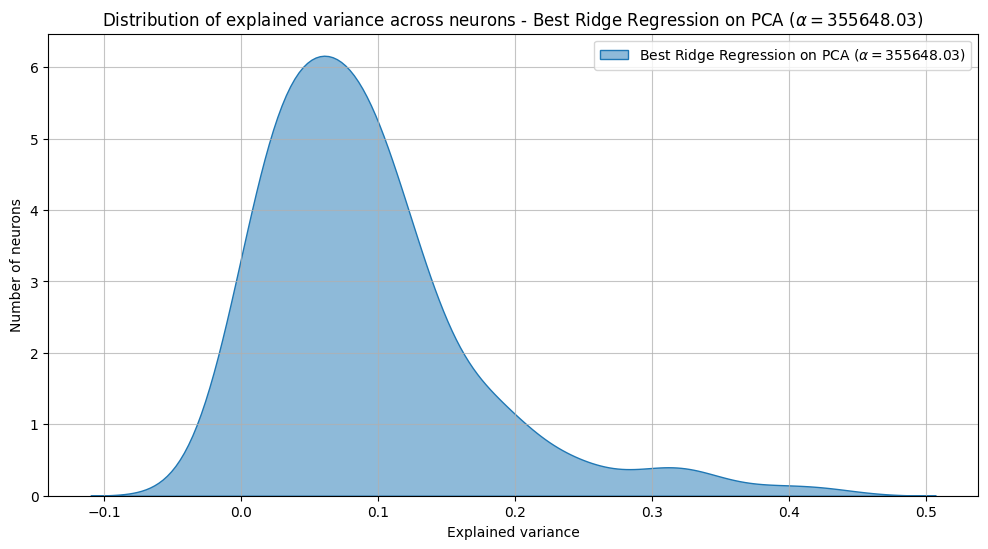

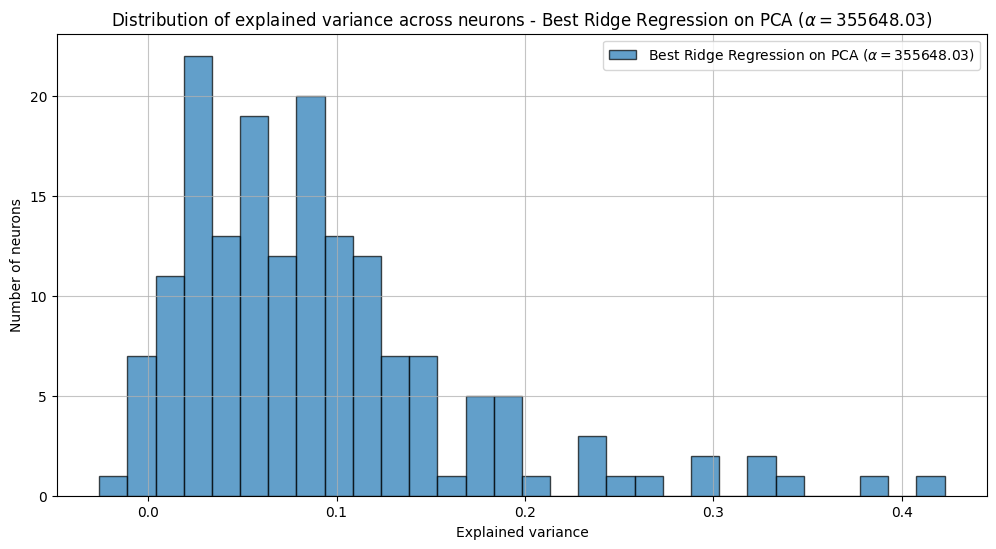

In [36]:
plot_ev_distributions([ev_best_ridge_pca], [model_best_ridge_pca], kde=True)
plot_ev_distributions([ev_best_ridge_pca], [model_best_ridge_pca], kde=False)

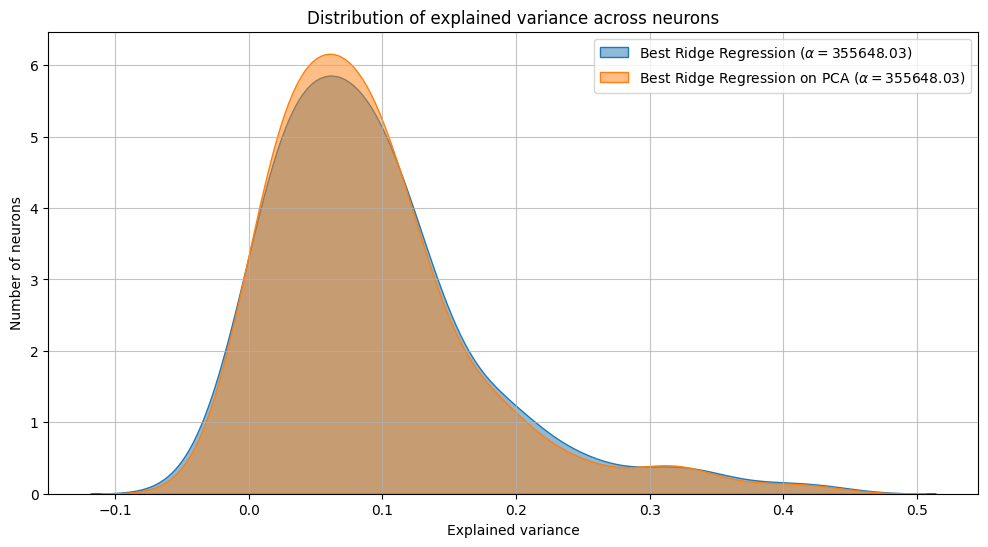

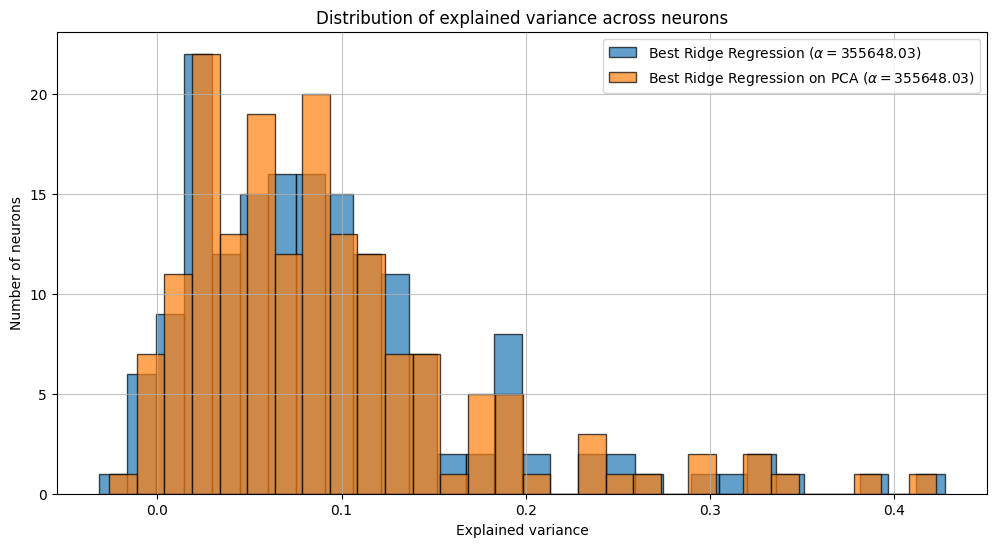

In [37]:
# Compare tuned ridge with PCA, and without PCA
plot_ev_distributions([ev_best_ridge, ev_best_ridge_pca], 
                      [model_best_ridge, model_best_ridge_pca], kde=True)
plot_ev_distributions([ev_best_ridge, ev_best_ridge_pca],
                      [model_best_ridge, model_best_ridge_pca], kde=False)

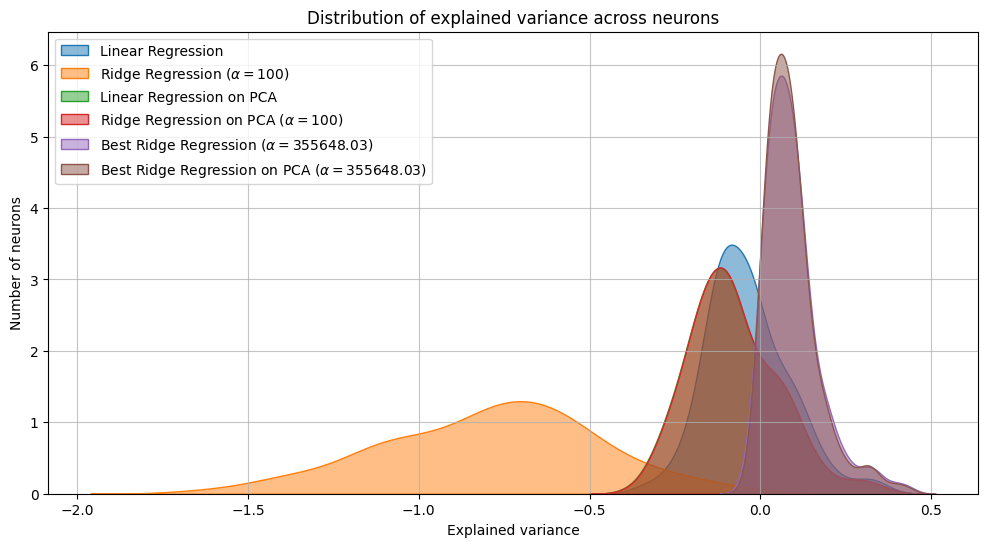

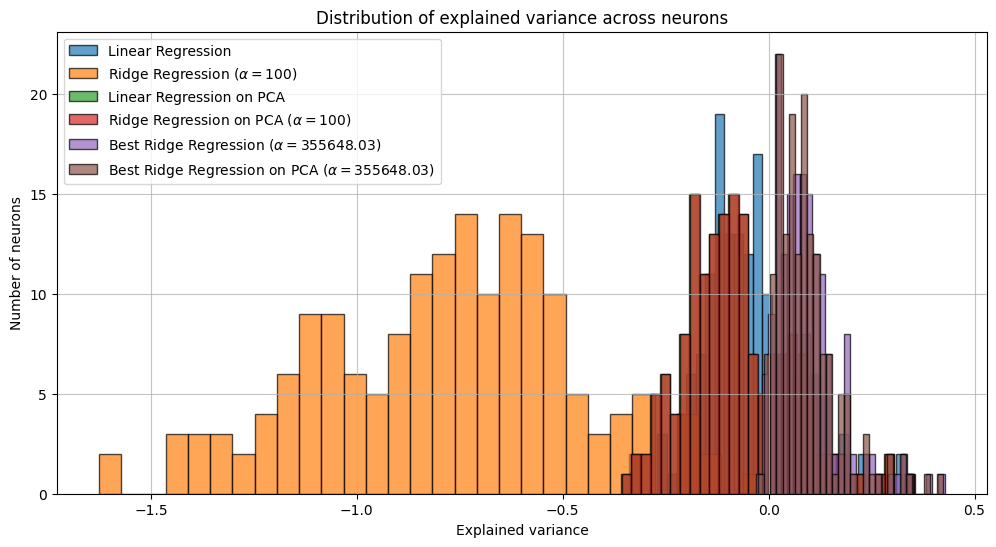

In [38]:
# Compare all models
plot_ev_distributions([ev_linear, ev_ridge, ev_linear_pca, ev_ridge_pca, ev_best_ridge, ev_best_ridge_pca], 
                      [model_linear, model_ridge, model_linear_pca, model_ridge_pca, model_best_ridge, model_best_ridge_pca], kde=True)
plot_ev_distributions([ev_linear, ev_ridge, ev_linear_pca, ev_ridge_pca, ev_best_ridge, ev_best_ridge_pca],
                      [model_linear, model_ridge, model_linear_pca, model_ridge_pca, model_best_ridge, model_best_ridge_pca], kde=False)

In [55]:
# Define the models and their corresponding metrics
models = [model_linear, model_ridge, model_linear_pca, model_ridge_pca, model_best_ridge, model_best_ridge_pca]
explained_variances = [mean_ev_linear, mean_ev_ridge, mean_ev_linear_pca, mean_ev_ridge_pca, mean_ev_best_ridge, mean_ev_best_ridge_pca]
correlations = [mean_corr_linear, mean_corr_ridge, mean_corr_linear_pca, mean_corr_ridge_pca, mean_corr_best_ridge, mean_corr_best_ridge_pca]

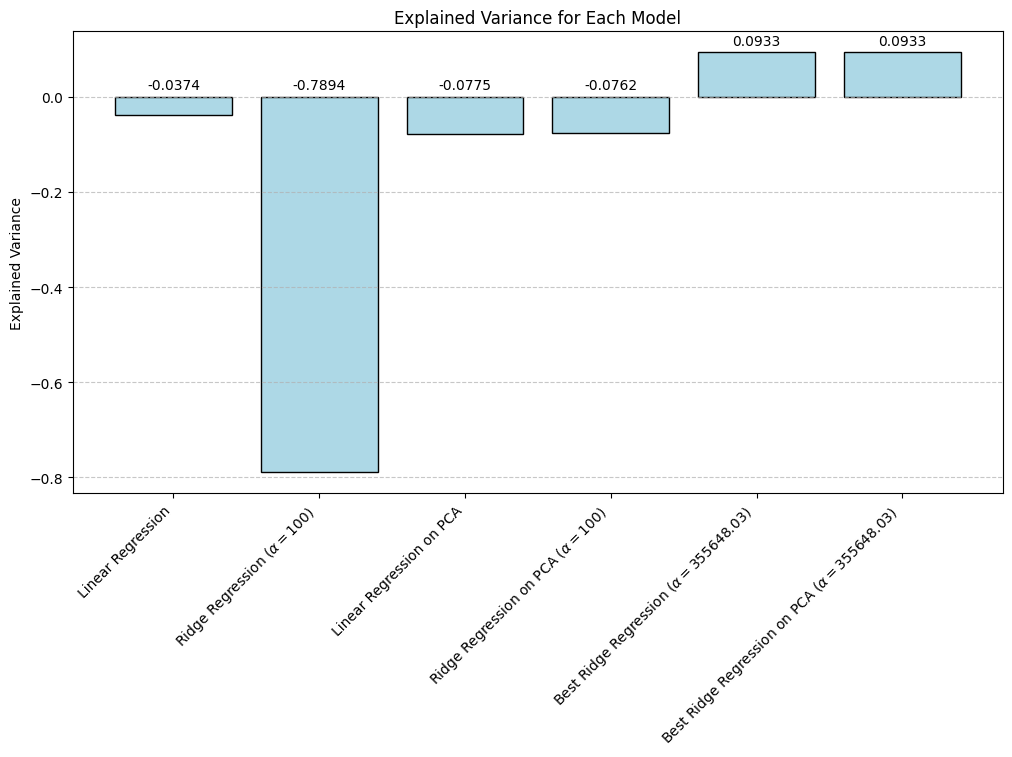

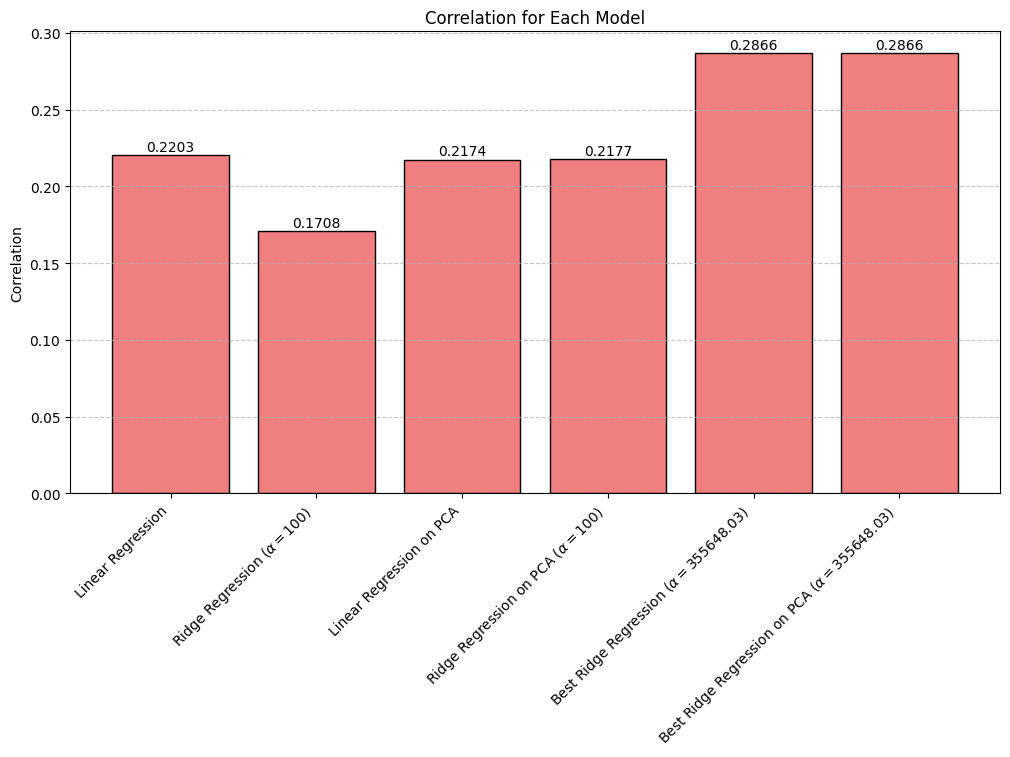

In [58]:
# Plot explained variance for each model
plt.figure(figsize=(12, 6))
plt.bar(models, explained_variances, color='lightblue', edgecolor='black')
for i, ev in enumerate(explained_variances):
    plt.text(i, max(0, ev) + 0.01, f"{ev:.4f}", ha='center', va='bottom', fontsize=10)
plt.title("Explained Variance for Each Model")
plt.ylabel("Explained Variance")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Plot correlation for each model
plt.figure(figsize=(12, 6))
plt.bar(models, correlations, color='lightcoral', edgecolor='black')
for i, corr in enumerate(correlations):
    plt.text(i, corr + 0.001, f"{corr:.4f}", ha='center', va='bottom', fontsize=10)
plt.title("Correlation for Each Model")
plt.ylabel("Correlation")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Part 2: Predict the neural activity with the task-driven modeling approach

As you have seen in the class, the underlying hypothesis of task-driven modeling is that training the network to perform a relevant behavioral task makes the network to develop representations that resemble the ones of the biological brain. Let's test this hypothesis by loading a pre-trained ResNet50 model and use the activations of each layer to predict the neural activity. Follow these steps:

- Give as input to the network the stimuli and extract the corresponding activations of the following layers ['conv1','layer1','layer2','layer3','layer4','avgpool']
- Compute the 1000 PCs for each layer activation. (Careful that you don't want to store all activations together at the same time because it won't fit in the memory. Therefore, compute the activations and corresponding PCs for each layer and store only the computed PCs).
- Use the PCs of each layer to predict the neural activity using the linear regression models you developed before.
- Compute the goodness of fit using the correlation and explained variance metrics. Do you predict the neural activity better than before?
- Plot the distribution of explained variance with respect to the layer of the network (order them based on the depth). How does the neural activity changes across the model layers, can you make some statements about it?
- Compare the predictions that you obtained using one layer of the pretrained model and the one obtained using the same layer but from a randomly initialized model. Which network can better predict the neural activity and why?

In [ ]:
import torch
from torchvision.models import resnet50, ResNet50_Weights
import torch.utils.data as data
import pickle

In [60]:
# --- Parameters ---
BATCH_SIZE = 64
LAYERS = ['conv1', 'layer1', 'layer2', 'layer3', 'layer4', 'avgpool']
N_COMPONENTS = 1000
ALPHA = 20
SAVE_PATH = "data/activationsResNet50"

In [ ]:
def extract_layer_activations(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, layers: list[str]) -> dict[str, np.ndarray]:
    """
    Extract activations from specified layers of a model for a given dataset.

    Parameters:
    - model (torch.nn.Module): The neural network model from which to extract activations.
    - dataloader (torch.utils.data.DataLoader): DataLoader providing input data in batches.
    - layers (list[str]): List of layer names to extract activations from.

    Returns:
    - dict[str, np.ndarray]: A dictionary where keys are layer names and values are the corresponding activations 
      as numpy arrays of shape (n_samples, ...).
    """
    
    activations: dict[str, list[np.ndarray]] = {layer: [] for layer in layers}

    def make_hook(layer_name):
        return lambda m, i, o: activations[layer_name].append(o.detach().cpu().numpy())

    # Register hooks for the specified layers
    hooks: list[torch.utils.hooks.RemovableHandle] = [
        getattr(model, name).register_forward_hook(make_hook(name)) for name in layers
    ]

    # Perform a forward pass through the model to collect activations
    with torch.no_grad():
        for batch in dataloader:
            x: torch.Tensor = torch.from_numpy(np.stack(batch).astype(np.float32))
            model(x)

    # Remove hooks after extraction
    for h in hooks:
        h.remove()

    # Concatenate activations for each layer
    return {k: np.concatenate(v, axis=0) for k, v in activations.items()}

In [ ]:
def compute_pca_features(data_dict: dict[str, np.ndarray], num_components: int = 1000) -> tuple[dict[str, np.ndarray], dict[str, PCA]]:
    """
    Compute PCA features for each layer's activations.

    Parameters:
    - data_dict (dict[str, np.ndarray]): Dictionary where keys are layer names and values are activations 
    - num_components (int): Number of principal components to retain.

    Returns:
    - tuple[dict[str, np.ndarray], dict[str, PCA]]: 
        - pca_features (dict[str, np.ndarray]): Dictionary where keys are layer names and values are PCA-transformed features.
        - pcas (dict[str, PCA]): Dictionary where keys are layer names and values are the fitted PCA objects.
    """
    pca_features: dict[str, np.ndarray] = {}
    pcas: dict[str, PCA] = {}
    for name, activations in data_dict.items():
        reshaped: np.ndarray = activations.reshape(activations.shape[0], -1)  # Flatten activations
        pca: PCA = PCA(n_components=num_components)
        pca_features[name] = pca.fit_transform(reshaped)  # Transform activations using PCA
        pcas[name] = pca  # Store the PCA object
    return pca_features, pcas

In [ ]:
def transform_with_pca(data_dict, pcas):
    return {
        name: pca.transform(data.reshape(data.shape[0], -1))
        for name, (data, pca) in zip(data_dict.keys(), zip(data_dict.values(), pcas.values()))
    }

In [61]:
def run_regression(X_train:np.ndarray, X_val:np.ndarray, y_train:np.ndarray, y_val:np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Train a Ridge regression model and evaluate it on the validation set.

    Args:
        X_train (np.ndarray): input for training
        X_val (np.ndarray): input for validation
        y_train (np.ndarray): target for training
        y_val (np.ndarray): target for validation

    Returns:
        tuple[np.ndarray, np.ndarray]: Pearson correlation and explained variance for the validation set.
    """
    model = Ridge(alpha=ALPHA, fit_intercept=True)
    model.fit(X_train, y_train)
    return evaluate_model(model, X_val, y_val)


In [ ]:
def run_analysis(stimulus_train:np.ndarray, stimulus_val:np.ndarray, pretrained:bool=True):
    weights = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
    model = resnet50(weights=weights).eval()

    loader_train = data.DataLoader(stimulus_train, batch_size=BATCH_SIZE, shuffle=False)
    loader_val = data.DataLoader(stimulus_val, batch_size=BATCH_SIZE, shuffle=False)

    train_acts = extract_layer_activations(model, loader_train, LAYERS)
    val_acts = extract_layer_activations(model, loader_val, LAYERS)

    pca_train, pcas = compute_pca_features(train_acts, N_COMPONENTS)
    pca_val = transform_with_pca(val_acts, pcas)

    # Optional save
    if pretrained:
        os.makedirs(SAVE_PATH, exist_ok=True)
        with open(os.path.join(SAVE_PATH, "pca_dict_train.pkl"), "wb") as f:
            pickle.dump(pca_train, f)
        with open(os.path.join(SAVE_PATH, "pca_dict_val.pkl"), "wb") as f:
            pickle.dump(pca_val, f)

    return pca_train, pca_val

In [ ]:
pca_imagenet_train, pca_imagenet_val = run_analysis(stimulus_train, stimulus_val, spikes_train, spikes_val, pretrained=True)
pca_random_train, pca_random_val = run_analysis(stimulus_train, stimulus_val, spikes_train, spikes_val, pretrained=False)

corr_img, ev_img = run_regression(pca_imagenet_train['layer3'], pca_imagenet_val['layer3'], spikes_train, spikes_val)
corr_rnd, ev_rnd = run_regression(pca_random_train['layer3'], pca_random_val['layer3'], spikes_train, spikes_val)

print(f"Imagenet Weights — EV: {ev_img:.3f}, Corr: {corr_img:.3f}")
print(f"Random Weights   — EV: {ev_rnd:.3f}, Corr: {corr_rnd:.3f}")
